Cerco file .npz in: /Users/benussi/Testbeam2026_WC_single/data
Trovati 200 file totali.

Eventi totali raccolti: 197454


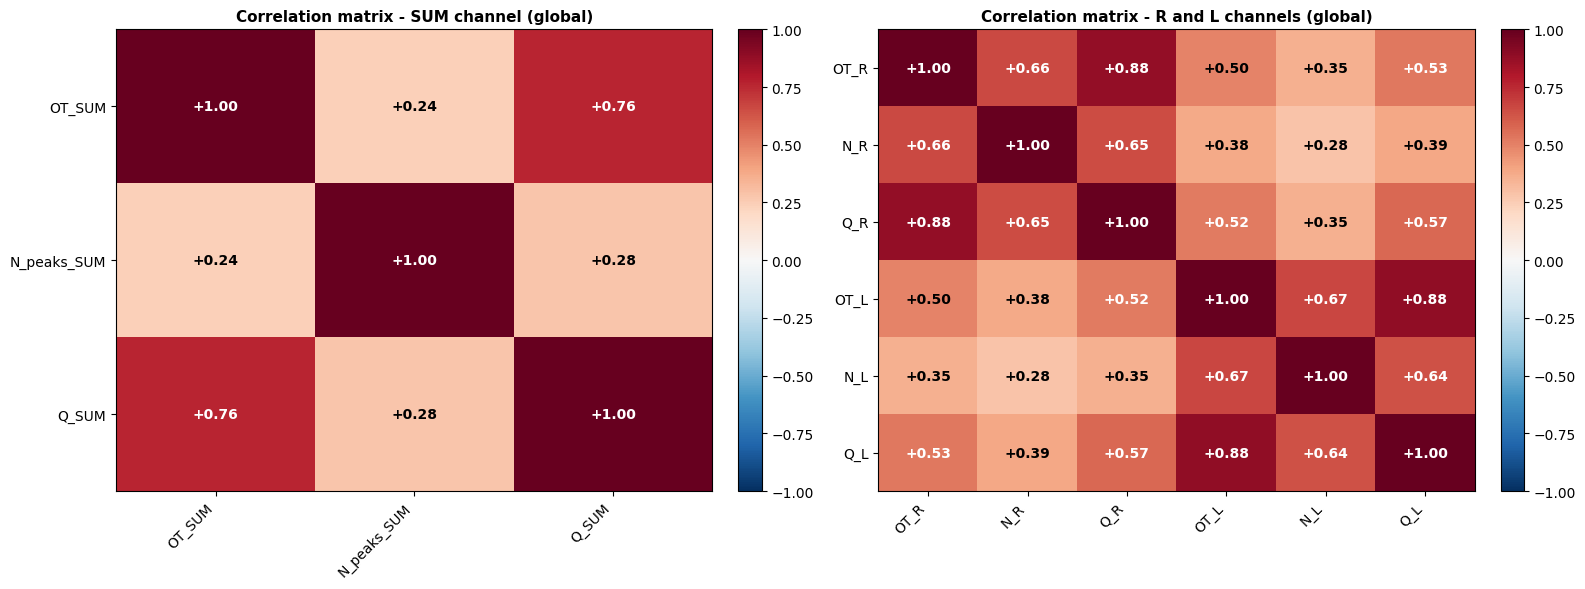


=== Correlation matrix (SUM, global) ===
                   OT_SUM  N_peaks_SUM        Q_SUM
OT_SUM             +1.000       +0.240       +0.763
N_peaks_SUM        +0.240       +1.000       +0.281
Q_SUM              +0.763       +0.281       +1.000

=== Correlation rho per angolo (SUM) ===
    angolo    rho(OT,Q)    rho(OT,N)     rho(N,Q)    N_evt
         0       +0.646       +0.168       +0.408    24182
        10       +0.655       +0.179       +0.403    24252
        20       +0.667       +0.166       +0.385    24469
        30       +0.663       +0.151       +0.348    24722
        40       +0.713       +0.174       +0.323    24884
        50       +0.636       +0.068       +0.186    24980
        60       +0.583       +0.015       +0.050    24975
        70       +0.538       -0.029       -0.060    24990

=== PCA delle osservabili (OT, N_peaks, Q) standardizzate ===
  PC1: eigenvalue = 1.912  (63.7% varianza spiegata)
  PC2: eigenvalue = 0.852  (28.4% varianza spiegata)
  PC3: e

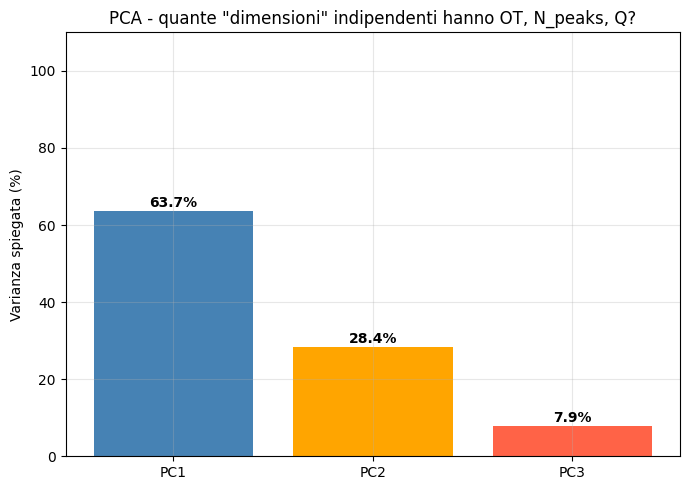

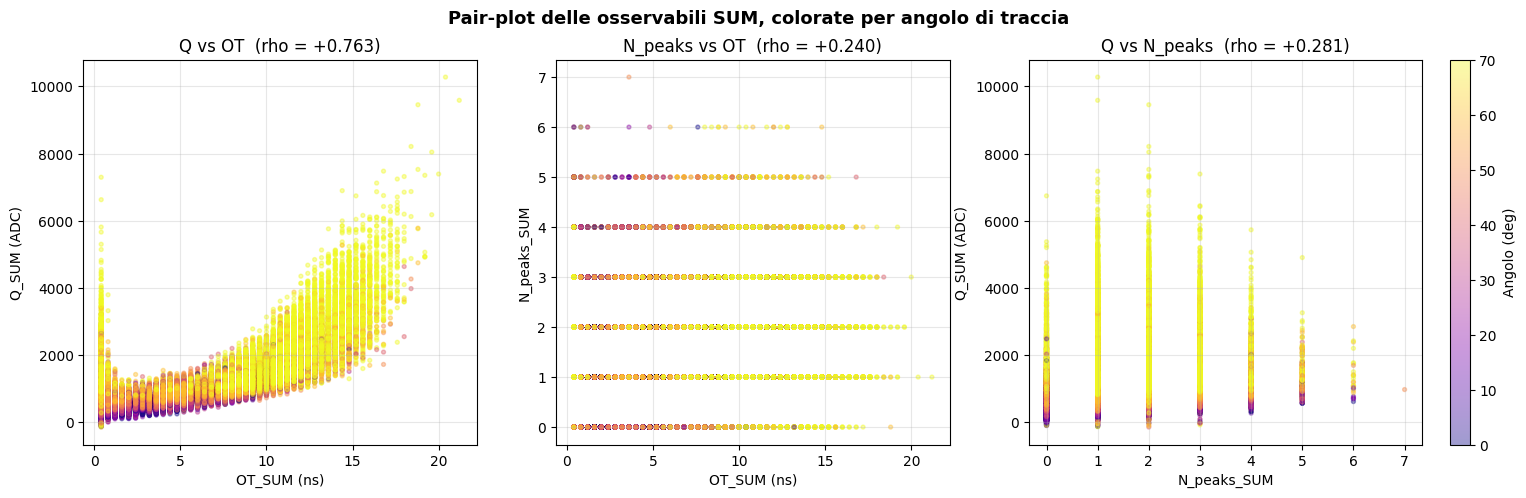


=== Calibrazione X da log(Q_R/Q_L) ===
  Fit: log(Q_R/Q_L) = -0.0018915 * X + -0.072
  λ_att = 1057 mm (105.7 cm)  [da slope = -2/λ_att]
  Residui X_rec - X_vero: mean = -0.0 mm, sigma = 293.1 mm

=== Calibrazione X da Δt = t_R - t_L ===
  Fit: Δt = +0.014354 * X + +0.564 ns
  v_eff = -139 mm/ns (-13.9 cm/ns)  [da slope = -2/v_eff]
  Residui X_rec - X_vero: mean = +0.0 mm, sigma = 92.5 mm

=== Stima X combinata (weighted) ===
  sigma_X (Q-only)    = 293.1 mm
  sigma_X (Δt-only)   = 92.5 mm
  sigma_X (combinata) = 92.3 mm  (atteso da media pesata: 88.2 mm)


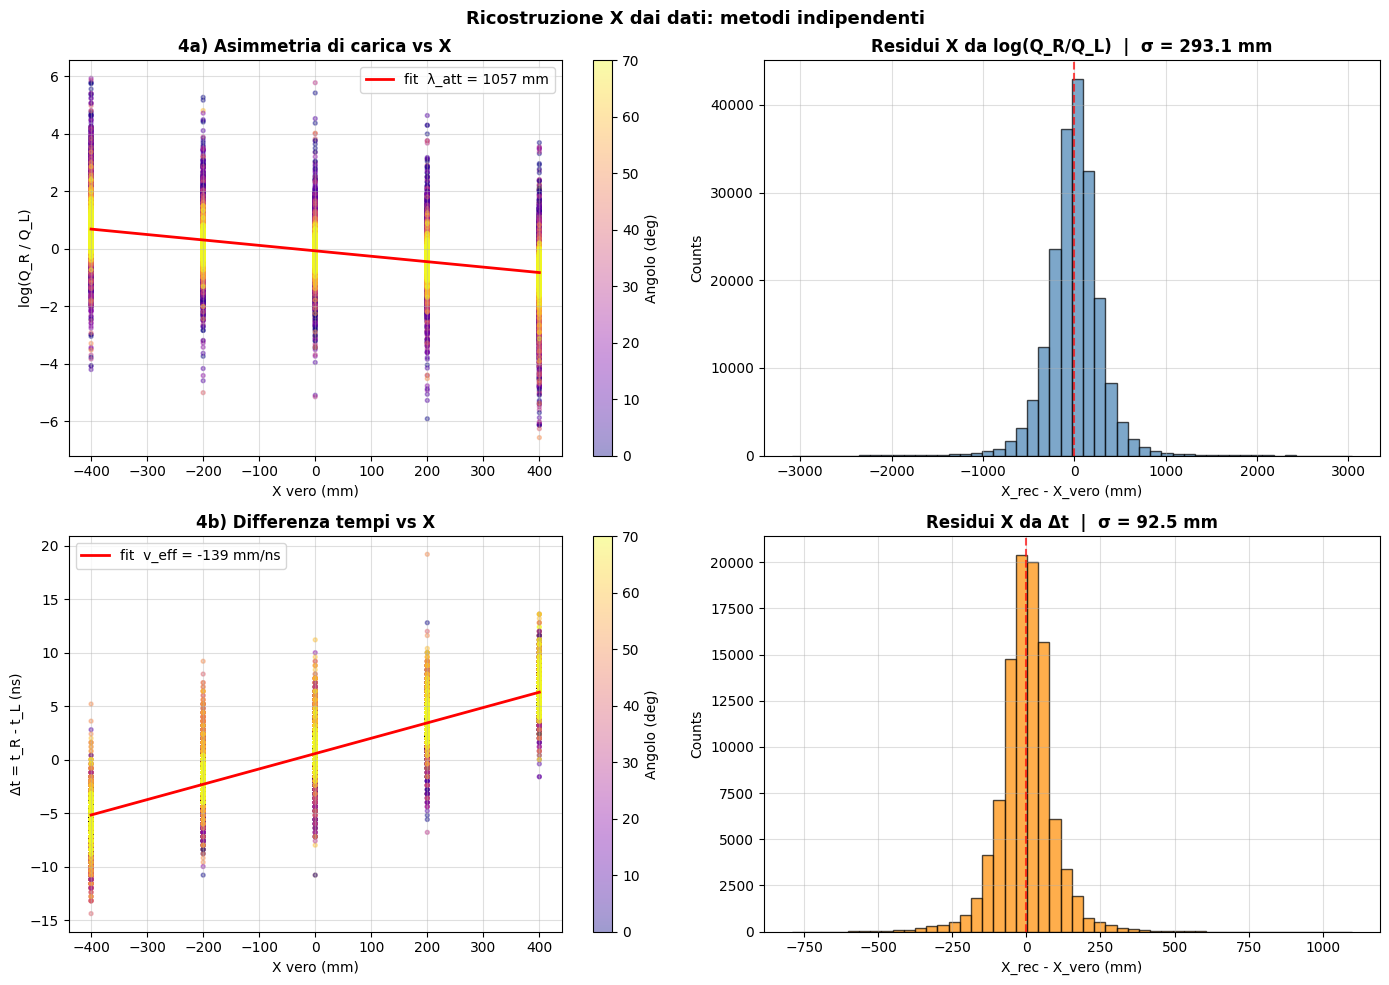

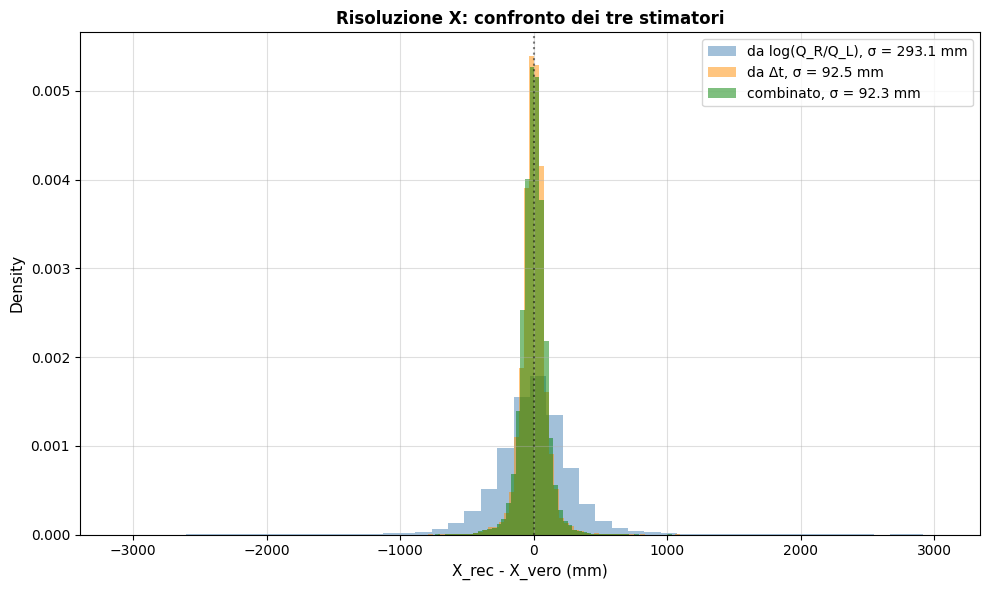

In [1]:
"""
============================================================
correlation_diagnostics.py
============================================================
Diagnostica multivariata delle osservabili OT, N_peaks, Q
e ricostruzione X dai dati (asimmetria carica + differenza tempi).

Output:
  1) Matrice di correlazione SUM (globale) + per angolo
  2) Matrice di correlazione (R, L) - per vedere ridondanze tra canali
  3) PCA: numero di dimensioni effettive
  4) Pair-plots delle osservabili SUM, colorate per angolo
  5) Calibrazione log(Q_R/Q_L) vs X_vero → λ_att, σ_X
  6) Calibrazione Δt vs X_vero → v_eff, σ_X
  7) Risoluzione X combinata (media pesata)

Riusa le stesse funzioni di calcolo di ot_vs_angle.py per coerenza.
"""

import os
import re
import glob
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eigh

# ============================================================
# PARAMETRI (allineati a ot_vs_angle.py)
# ============================================================
MC_DIR = "/Users/benussi/Testbeam2026_WC_single/data"

SAMPLE_RATE_GS = 2.5
DT_NS         = 1.0 / SAMPLE_RATE_GS
RECORD_LENGTH = 1024
BASELINE_ADC  = 3800
V_PP_MV       = 1000.0
ADC_BITS      = 12
LSB_MV        = V_PP_MV / (2**ADC_BITS)

CHANNEL_DEFS = {'R': [0], 'L': [1], 'SUM': [0, 1]}

OT_THRESHOLD_MV         = 5.0
PEAK_THRESHOLD_MV       = 5.0
PEAK_MIN_DISTANCE_NS    = 1.5
PEAK_MIN_PROMINENCE_MV  = 3.0
PEAK_MIN_DIST_SAMPLES   = max(int(PEAK_MIN_DISTANCE_NS / DT_NS), 1)

INTEGRAL_GATE_PRE_NS    = 2.0
INTEGRAL_GATE_POST_NS   = 100.0

TRIGGER_NS = 150.0
ROI_START_NS = TRIGGER_NS - 100.0
ROI_END_NS   = TRIGGER_NS + 59.0
ROI_START_SAMPLE = int(ROI_START_NS / DT_NS)
ROI_END_SAMPLE   = int(ROI_END_NS / DT_NS)

FNAME_REGEX = re.compile(
    r'sim_Z([+-]?\d+\.?\d*)_Y([+-]?\d+\.?\d*)_X([+-]?\d+\.?\d*)_([+-]?\d+\.?\d*)Deg\.npz',
    re.IGNORECASE
)

# ============================================================
# FUNZIONI (copia da ot_vs_angle.py)
# ============================================================
def parse_fname(fname):
    m = FNAME_REGEX.match(fname)
    if not m: return None
    return float(m.group(1)), float(m.group(2)), float(m.group(3)), float(m.group(4))

def summed_signal_mv(event_dict, channels):
    summed = np.zeros(RECORD_LENGTH, dtype=float)
    for ch in channels:
        key = f'ch_{ch}'
        if key not in event_dict: continue
        wf = event_dict[key].astype(float)
        summed += -(wf - BASELINE_ADC) * LSB_MV
    return summed

def compute_ot(summed_mv, threshold_mv, roi_start, roi_end):
    if roi_start < 0: roi_start = 0
    if roi_end > RECORD_LENGTH: roi_end = RECORD_LENGTH
    above = summed_mv[roi_start:roi_end] > threshold_mv
    if not above.any():
        return 0.0, -1, -1
    idx_above = np.where(above)[0]
    rising_local = idx_above[0]
    below_after = np.where(~above[rising_local:])[0]
    if len(below_after) == 0:
        falling_local = len(above) - 1
    else:
        falling_local = rising_local + below_after[0] - 1
    ot_ns = (falling_local - rising_local + 1) * DT_NS
    return ot_ns, roi_start + rising_local, roi_start + falling_local

def _local_maxima(sig):
    if len(sig) < 3: return np.array([], dtype=int)
    d = np.diff(sig)
    rising = d[:-1] > 0
    falling = d[1:]  < 0
    return np.where(rising & falling)[0] + 1

def _prominence(sig, peaks):
    n = len(sig)
    out = np.empty(len(peaks), dtype=float)
    for k, p in enumerate(peaks):
        h = sig[p]
        left_min = h
        i = p - 1
        while i >= 0 and sig[i] <= h:
            if sig[i] < left_min: left_min = sig[i]
            i -= 1
        right_min = h
        i = p + 1
        while i < n and sig[i] <= h:
            if sig[i] < right_min: right_min = sig[i]
            i += 1
        out[k] = h - max(left_min, right_min)
    return out

def _find_peaks(sig, height=None, distance=None, prominence=None):
    peaks = _local_maxima(sig)
    if len(peaks) == 0: return peaks
    if height is not None:
        peaks = peaks[sig[peaks] >= height]
        if len(peaks) == 0: return peaks
    if prominence is not None and len(peaks) > 0:
        proms = _prominence(sig, peaks)
        peaks = peaks[proms >= prominence]
        if len(peaks) == 0: return peaks
    if distance is not None and distance > 1 and len(peaks) > 1:
        heights = sig[peaks]
        order = np.argsort(-heights)
        keep = np.ones(len(peaks), dtype=bool)
        for idx in order:
            if not keep[idx]: continue
            for other in range(len(peaks)):
                if other != idx and keep[other]:
                    if abs(peaks[other] - peaks[idx]) < distance:
                        keep[other] = False
        peaks = peaks[keep]
        peaks = np.sort(peaks)
    return peaks

def count_peaks(summed_mv, threshold_mv, roi_start, roi_end,
                min_dist_samples, min_prominence_mv, start_from=None):
    if roi_start < 0: roi_start = 0
    if roi_end > RECORD_LENGTH: roi_end = RECORD_LENGTH
    if start_from is not None and start_from > roi_start:
        roi_start = start_from
    if roi_start >= roi_end: return 0
    sig = summed_mv[roi_start:roi_end]
    peaks_local = _find_peaks(sig, height=threshold_mv,
                              distance=min_dist_samples,
                              prominence=min_prominence_mv)
    return len(peaks_local)

def compute_integral(summed_mv, rising_sample, gate_pre_ns, gate_post_ns):
    if rising_sample < 0: return 0.0
    pre_samples  = int(round(gate_pre_ns  / DT_NS))
    post_samples = int(round(gate_post_ns / DT_NS))
    gate_start = max(0, rising_sample - pre_samples)
    gate_end   = min(RECORD_LENGTH, rising_sample + post_samples + 1)
    if gate_start >= gate_end: return 0.0
    return np.sum(summed_mv[gate_start:gate_end]) / LSB_MV


# ============================================================
# LOOP SUI FILE: raccoglie tutte le osservabili in una tabella
# ============================================================
print(f"Cerco file .npz in: {MC_DIR}")
files = sorted(glob.glob(os.path.join(MC_DIR, "*.npz")))
print(f"Trovati {len(files)} file totali.")

events = []
for fpath in files:
    fname = os.path.basename(fpath)
    parsed = parse_fname(fname)
    if parsed is None:
        continue
    Z_pos, Y_pos, X_pos, deg = parsed

    try:
        data = np.load(fpath, allow_pickle=True)
    except Exception as e:
        print(f"  [!] Errore lettura {fname}: {e}")
        continue

    for key_evt in data.files:
        ev = data[key_evt].item()

        wf_R = summed_signal_mv(ev, [0])
        wf_L = summed_signal_mv(ev, [1])
        wf_S = wf_R + wf_L

        ot_R, rR, _ = compute_ot(wf_R, OT_THRESHOLD_MV, ROI_START_SAMPLE, ROI_END_SAMPLE)
        ot_L, rL, _ = compute_ot(wf_L, OT_THRESHOLD_MV, ROI_START_SAMPLE, ROI_END_SAMPLE)
        ot_S, rS, _ = compute_ot(wf_S, OT_THRESHOLD_MV, ROI_START_SAMPLE, ROI_END_SAMPLE)

        # Selezione: tieni solo eventi con pulse valido sulla SUM
        if ot_S <= 0:
            continue

        nR = count_peaks(wf_R, PEAK_THRESHOLD_MV, ROI_START_SAMPLE, ROI_END_SAMPLE,
                         PEAK_MIN_DIST_SAMPLES, PEAK_MIN_PROMINENCE_MV,
                         start_from=rR if rR >= 0 else None)
        nL = count_peaks(wf_L, PEAK_THRESHOLD_MV, ROI_START_SAMPLE, ROI_END_SAMPLE,
                         PEAK_MIN_DIST_SAMPLES, PEAK_MIN_PROMINENCE_MV,
                         start_from=rL if rL >= 0 else None)
        nS = count_peaks(wf_S, PEAK_THRESHOLD_MV, ROI_START_SAMPLE, ROI_END_SAMPLE,
                         PEAK_MIN_DIST_SAMPLES, PEAK_MIN_PROMINENCE_MV,
                         start_from=rS if rS >= 0 else None)

        Q_R = compute_integral(wf_R, rS, INTEGRAL_GATE_PRE_NS, INTEGRAL_GATE_POST_NS)
        Q_L = compute_integral(wf_L, rS, INTEGRAL_GATE_PRE_NS, INTEGRAL_GATE_POST_NS)
        Q_S = compute_integral(wf_S, rS, INTEGRAL_GATE_PRE_NS, INTEGRAL_GATE_POST_NS)

        t_R = rR * DT_NS if rR >= 0 else np.nan
        t_L = rL * DT_NS if rL >= 0 else np.nan
        dt  = (t_R - t_L) if (rR >= 0 and rL >= 0) else np.nan

        events.append({
            'deg': deg, 'X': X_pos, 'Y': Y_pos, 'Z': Z_pos,
            'OT_R': ot_R, 'OT_L': ot_L, 'OT_S': ot_S,
            'N_R': nR,    'N_L': nL,    'N_S': nS,
            'Q_R': Q_R,   'Q_L': Q_L,   'Q_S': Q_S,
            't_R': t_R,   't_L': t_L,   'dt':  dt,
        })

print(f"\nEventi totali raccolti: {len(events)}")

# Converti in dict di array per analisi vettorializzata
keys_all = events[0].keys()
D = {k: np.array([e[k] for e in events], dtype=float) for k in keys_all}


# ============================================================
# 1) MATRICI DI CORRELAZIONE
# ============================================================
def plot_corr(corr, labels, title, ax):
    im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_yticklabels(labels)
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, f'{corr[i,j]:+.2f}', ha='center', va='center',
                    color='white' if abs(corr[i,j]) > 0.5 else 'black',
                    fontsize=10, fontweight='bold')
    ax.set_title(title, fontsize=11, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Matrice 3x3 SUM (OT, N, Q)
vars_S = ['OT_S', 'N_S', 'Q_S']
lab_S  = ['OT_SUM', 'N_peaks_SUM', 'Q_SUM']
M_S = np.column_stack([D[v] for v in vars_S])
corr_S = np.corrcoef(M_S.T)

# Matrice 6x6 (R + L)
vars_RL = ['OT_R', 'N_R', 'Q_R', 'OT_L', 'N_L', 'Q_L']
M_RL = np.column_stack([D[v] for v in vars_RL])
corr_RL = np.corrcoef(M_RL.T)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_corr(corr_S,  lab_S,  'Correlation matrix - SUM channel (global)', axes[0])
plot_corr(corr_RL, vars_RL,'Correlation matrix - R and L channels (global)', axes[1])
fig.tight_layout()
plt.show()

print("\n=== Correlation matrix (SUM, global) ===")
print(f"{'':<12} " + " ".join(f'{l:>12}' for l in lab_S))
for i, l in enumerate(lab_S):
    print(f"{l:<12} " + " ".join(f'{corr_S[i,j]:>+12.3f}' for j in range(3)))

print("\n=== Correlation rho per angolo (SUM) ===")
print(f"  {'angolo':>8} {'rho(OT,Q)':>12} {'rho(OT,N)':>12} {'rho(N,Q)':>12} {'N_evt':>8}")
for deg_val in sorted(set(D['deg'])):
    mask = D['deg'] == deg_val
    if mask.sum() < 10: continue
    Ma = np.column_stack([D['OT_S'][mask], D['N_S'][mask], D['Q_S'][mask]])
    c = np.corrcoef(Ma.T)
    print(f"  {deg_val:>8.0f} {c[0,2]:>+12.3f} {c[0,1]:>+12.3f} {c[1,2]:>+12.3f} {mask.sum():>8d}")


# ============================================================
# 2) PCA delle osservabili SUM
# ============================================================
# Standardizzo: (x - mean) / std
M_std = (M_S - M_S.mean(0)) / M_S.std(0)
cov_std = np.cov(M_std.T)
eigvals, eigvecs = eigh(cov_std)
order = np.argsort(-eigvals)
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]
explained_ratio = eigvals / eigvals.sum()

print(f"\n=== PCA delle osservabili (OT, N_peaks, Q) standardizzate ===")
for i, (lam, ratio) in enumerate(zip(eigvals, explained_ratio)):
    print(f"  PC{i+1}: eigenvalue = {lam:.3f}  ({ratio*100:.1f}% varianza spiegata)")
print(f"  Dimensioni effettive (PC con ratio > 5%): "
      f"{int((explained_ratio > 0.05).sum())} su 3")

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(['PC1', 'PC2', 'PC3'], explained_ratio*100, color=['steelblue', 'orange', 'tomato'])
ax.set_ylabel('Varianza spiegata (%)')
ax.set_title('PCA - quante "dimensioni" indipendenti hanno OT, N_peaks, Q?')
for i, r in enumerate(explained_ratio):
    ax.text(i, r*100 + 1, f'{r*100:.1f}%', ha='center', fontweight='bold')
ax.grid(alpha=0.3)
ax.set_ylim(0, 110)
plt.tight_layout()
plt.show()


# ============================================================
# 3) PAIR PLOTS (OT vs Q, OT vs N, N vs Q) colorati per angolo
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
deg_arr = D['deg']
cmap = plt.cm.plasma
norm = plt.Normalize(vmin=deg_arr.min(), vmax=deg_arr.max())

axes[0].scatter(D['OT_S'], D['Q_S'], c=deg_arr, cmap=cmap, norm=norm, alpha=0.4, s=8)
axes[0].set_xlabel('OT_SUM (ns)'); axes[0].set_ylabel('Q_SUM (ADC)')
axes[0].set_title(f'Q vs OT  (rho = {corr_S[0,2]:+.3f})')
axes[0].grid(alpha=0.3)

axes[1].scatter(D['OT_S'], D['N_S'], c=deg_arr, cmap=cmap, norm=norm, alpha=0.4, s=8)
axes[1].set_xlabel('OT_SUM (ns)'); axes[1].set_ylabel('N_peaks_SUM')
axes[1].set_title(f'N_peaks vs OT  (rho = {corr_S[0,1]:+.3f})')
axes[1].grid(alpha=0.3)

sc = axes[2].scatter(D['N_S'], D['Q_S'], c=deg_arr, cmap=cmap, norm=norm, alpha=0.4, s=8)
axes[2].set_xlabel('N_peaks_SUM'); axes[2].set_ylabel('Q_SUM (ADC)')
axes[2].set_title(f'Q vs N_peaks  (rho = {corr_S[1,2]:+.3f})')
axes[2].grid(alpha=0.3)

cbar = fig.colorbar(sc, ax=axes, label='Angolo (deg)', fraction=0.02, pad=0.02)
fig.suptitle('Pair-plot delle osservabili SUM, colorate per angolo di traccia',
             fontsize=13, fontweight='bold')
plt.show()


# ============================================================
# 4) RICOSTRUZIONE X DA log(Q_R/Q_L) E DA Δt
# ============================================================
# Filtri di validità
mask_Q  = (D['Q_R'] > 0) & (D['Q_L'] > 0)
mask_dt = np.isfinite(D['dt'])

# === 4a) log(Q_R/Q_L) vs X_vero ===
log_QR_QL = np.log(D['Q_R'][mask_Q] / D['Q_L'][mask_Q])
X_for_logQ = D['X'][mask_Q]
slope_Q, intercept_Q = np.polyfit(X_for_logQ, log_QR_QL, 1)
# Modello Beer-Lambert simmetrico: log(Q_R/Q_L) = -2X/lambda
# slope = -2/lambda  →  lambda = -2/slope (in mm)
lambda_att = -2.0 / slope_Q if slope_Q != 0 else np.inf

# Inverto: X_rec = (log_QR_QL - intercept) / slope
X_rec_Q = (log_QR_QL - intercept_Q) / slope_Q
res_Q = X_rec_Q - X_for_logQ
sigma_X_Q = res_Q.std()

print(f"\n=== Calibrazione X da log(Q_R/Q_L) ===")
print(f"  Fit: log(Q_R/Q_L) = {slope_Q:+.5g} * X + {intercept_Q:+.3f}")
print(f"  λ_att = {lambda_att:.0f} mm ({lambda_att/10:.1f} cm)  "
      f"[da slope = -2/λ_att]")
print(f"  Residui X_rec - X_vero: mean = {res_Q.mean():+.1f} mm, "
      f"sigma = {sigma_X_Q:.1f} mm")

# === 4b) Δt vs X_vero ===
dt_arr = D['dt'][mask_dt]
X_for_dt = D['X'][mask_dt]
slope_dt, intercept_dt = np.polyfit(X_for_dt, dt_arr, 1)
# Modello: Δt = -2X/v_eff
v_eff = -2.0 / slope_dt if slope_dt != 0 else np.inf

X_rec_T = (dt_arr - intercept_dt) / slope_dt
res_T = X_rec_T - X_for_dt
sigma_X_T = res_T.std()

print(f"\n=== Calibrazione X da Δt = t_R - t_L ===")
print(f"  Fit: Δt = {slope_dt:+.5g} * X + {intercept_dt:+.3f} ns")
print(f"  v_eff = {v_eff:.0f} mm/ns ({v_eff/10:.1f} cm/ns)  "
      f"[da slope = -2/v_eff]")
print(f"  Residui X_rec - X_vero: mean = {res_T.mean():+.1f} mm, "
      f"sigma = {sigma_X_T:.1f} mm")

# === 4c) Combinazione weighted ===
both = mask_Q & mask_dt
log_full = np.log(D['Q_R'][both] / D['Q_L'][both])
dt_full  = D['dt'][both]
X_true   = D['X'][both]
X_rec_Q_b = (log_full - intercept_Q)  / slope_Q
X_rec_T_b = (dt_full  - intercept_dt) / slope_dt

w_Q = 1.0 / sigma_X_Q**2
w_T = 1.0 / sigma_X_T**2
X_rec_C = (w_Q * X_rec_Q_b + w_T * X_rec_T_b) / (w_Q + w_T)
res_C   = X_rec_C - X_true
sigma_X_C = res_C.std()
sigma_X_C_expected = 1.0 / np.sqrt(w_Q + w_T)

print(f"\n=== Stima X combinata (weighted) ===")
print(f"  sigma_X (Q-only)    = {sigma_X_Q:.1f} mm")
print(f"  sigma_X (Δt-only)   = {sigma_X_T:.1f} mm")
print(f"  sigma_X (combinata) = {sigma_X_C:.1f} mm  "
      f"(atteso da media pesata: {sigma_X_C_expected:.1f} mm)")

# === 4d) Plot calibrazioni e residui ===
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
# Scatter colorato per angolo
sc = ax.scatter(X_for_logQ, log_QR_QL, c=D['deg'][mask_Q], cmap='plasma',
                alpha=0.4, s=8)
Xr = np.linspace(X_for_logQ.min(), X_for_logQ.max(), 100)
ax.plot(Xr, slope_Q*Xr + intercept_Q, '-r', linewidth=2,
        label=f'fit  λ_att = {lambda_att:.0f} mm')
ax.set_xlabel('X vero (mm)'); ax.set_ylabel('log(Q_R / Q_L)')
ax.set_title('4a) Asimmetria di carica vs X', fontweight='bold')
ax.legend(); ax.grid(alpha=0.4)
plt.colorbar(sc, ax=ax, label='Angolo (deg)')

ax = axes[0, 1]
ax.hist(res_Q, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
ax.axvline(0, color='red', linestyle='--', alpha=0.7)
ax.set_xlabel('X_rec - X_vero (mm)')
ax.set_ylabel('Counts')
ax.set_title(f'Residui X da log(Q_R/Q_L)  |  σ = {sigma_X_Q:.1f} mm',
             fontweight='bold')
ax.grid(alpha=0.4)

ax = axes[1, 0]
sc = ax.scatter(X_for_dt, dt_arr, c=D['deg'][mask_dt], cmap='plasma',
                alpha=0.4, s=8)
Xr = np.linspace(X_for_dt.min(), X_for_dt.max(), 100)
ax.plot(Xr, slope_dt*Xr + intercept_dt, '-r', linewidth=2,
        label=f'fit  v_eff = {v_eff:.0f} mm/ns')
ax.set_xlabel('X vero (mm)'); ax.set_ylabel('Δt = t_R - t_L (ns)')
ax.set_title('4b) Differenza tempi vs X', fontweight='bold')
ax.legend(); ax.grid(alpha=0.4)
plt.colorbar(sc, ax=ax, label='Angolo (deg)')

ax = axes[1, 1]
ax.hist(res_T, bins=50, alpha=0.7, color='darkorange', edgecolor='black')
ax.axvline(0, color='red', linestyle='--', alpha=0.7)
ax.set_xlabel('X_rec - X_vero (mm)')
ax.set_ylabel('Counts')
ax.set_title(f'Residui X da Δt  |  σ = {sigma_X_T:.1f} mm',
             fontweight='bold')
ax.grid(alpha=0.4)

fig.suptitle('Ricostruzione X dai dati: metodi indipendenti',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


# === 4e) Confronto risoluzioni X ===
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(res_Q, bins=50, alpha=0.5, color='steelblue', density=True,
        label=f'da log(Q_R/Q_L), σ = {sigma_X_Q:.1f} mm')
ax.hist(res_T, bins=50, alpha=0.5, color='darkorange', density=True,
        label=f'da Δt, σ = {sigma_X_T:.1f} mm')
ax.hist(res_C, bins=50, alpha=0.5, color='green', density=True,
        label=f'combinato, σ = {sigma_X_C:.1f} mm')
ax.set_xlabel('X_rec - X_vero (mm)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.legend(fontsize=10)
ax.grid(alpha=0.4)
ax.set_title('Risoluzione X: confronto dei tre stimatori',
             fontsize=12, fontweight='bold')
ax.axvline(0, color='black', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()